In [ ]:
import numpy as np
import pandas as pd
import cv2
import PIL
import matplotlib.pyplot as plt
import random
import seaborn as sns
import plotly.express as px
import glob

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = "basantaly"
os.environ["KAGGLE_KEY"] = "7472dbbed394fc162a3ac71604bdc110"

In [ ]:
!kaggle  datasets download -d paultimothymooney/breast-histopathology-images

100% 3.10G/3.10G [00:42<00:00, 34.0MB/s]
100% 3.10G/3.10G [00:42<00:00, 78.4MB/s]


In [ ]:
! unzip -q "/content/breast-histopathology-images.zip"

In [ ]:
Data = glob.glob('/content/IDC_regular_ps50_idx5/**/*.png', recursive = True)

In [ ]:
for imgname in Data[:5]:
    print(imgname)

/content/IDC_regular_ps50_idx5/14189/1/14189_idx5_x1851_y1051_class1.png
/content/IDC_regular_ps50_idx5/14189/1/14189_idx5_x1651_y1701_class1.png
/content/IDC_regular_ps50_idx5/14189/1/14189_idx5_x1601_y1501_class1.png
/content/IDC_regular_ps50_idx5/14189/1/14189_idx5_x2051_y1851_class1.png
/content/IDC_regular_ps50_idx5/14189/1/14189_idx5_x2301_y1651_class1.png


In [ ]:
non_can_img = []
can_img = []

for img in Data:
    if img[-5] == '0' :
        non_can_img.append(img)

    elif img[-5] == '1' :
        can_img.append(img)

In [ ]:
non_can_num = len(non_can_img)  # No cancer
can_num = len(can_img)   # Cancer

total_img_num = non_can_num + can_num

print('Number of Images of no cancer: {}' .format(non_can_num))   # images of Non cancer
print('Number of Images of cancer : {}' .format(can_num))   # images of cancer
print('Total Number of Images : {}' .format(total_img_num))

Number of Images of no cancer: 198738
Number of Images of cancer : 78786
Total Number of Images : 277524


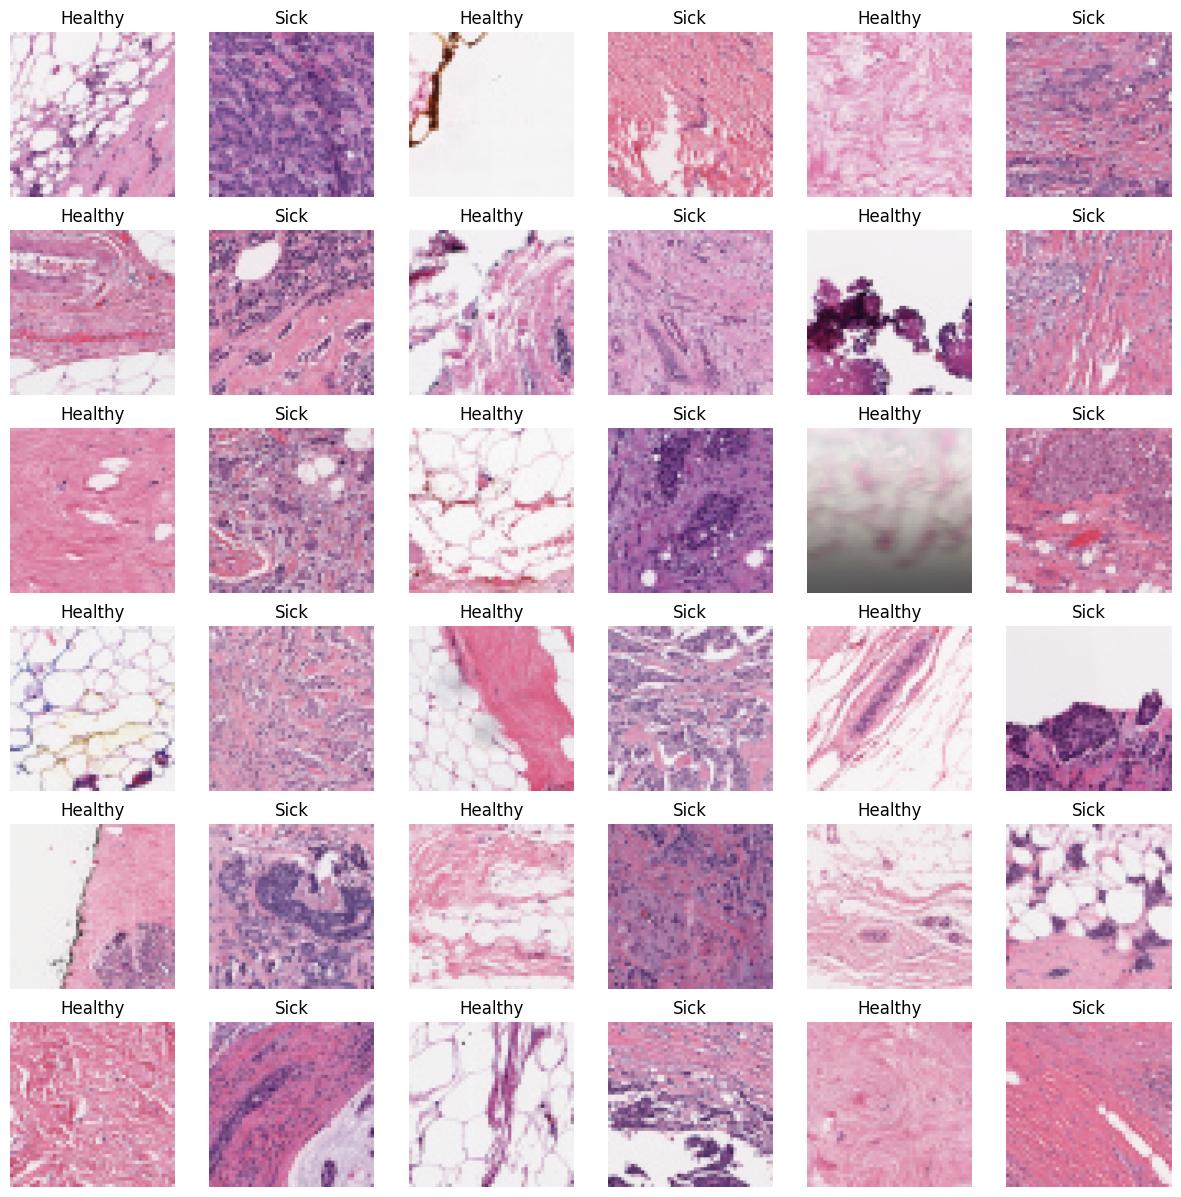

In [ ]:
from tensorflow.keras.preprocessing import image

plt.figure(figsize = (15, 15))

some_non = np.random.randint(0, len(non_can_img), 18)
some_can = np.random.randint(0, len(can_img), 18)

s = 0
for num in some_non:

        img = image.load_img((non_can_img[num]), target_size=(100, 100))
        img = image.img_to_array(img)

        plt.subplot(6, 6, 2*s+1)
        plt.axis('off')
        plt.title('Healthy')
        plt.imshow(img.astype('uint8'))
        s += 1

s = 1
for num in some_can:

        img = image.load_img((can_img[num]), target_size=(100, 100))
        img = image.img_to_array(img)
        plt.subplot(6, 6, 2*s)
        plt.axis('off')
        plt.title('Sick')
        plt.imshow(img.astype('uint8'))
        s += 1

In [ ]:
from matplotlib.image import imread
import cv2

some_non_img = random.sample(non_can_img, len(non_can_img))
some_can_img = random.sample(can_img, len(can_img))

non_img_arr = []
can_img_arr = []

for img in some_non_img:

    n_img = cv2.imread(img, cv2.IMREAD_COLOR)
    n_img_color = cv2.cvtColor(n_img, cv2.COLOR_BGR2RGB)
    n_img_size = cv2.resize(n_img_color, (50, 50), interpolation = cv2.INTER_LINEAR)
    n_img_smooth = cv2.GaussianBlur(n_img_size, (5, 5), 0)
    non_img_arr.append([n_img_smooth, 0])

for img in some_can_img:

    c_img = cv2.imread(img, cv2.IMREAD_COLOR)
    c_img_color = cv2.cvtColor(c_img, cv2.COLOR_BGR2RGB)
    c_img_size = cv2.resize(c_img_color, (50, 50), interpolation = cv2.INTER_LINEAR)
    c_img_smooth = cv2.GaussianBlur(c_img_size, (5, 5), 0)
    can_img_arr.append([c_img_smooth, 1])

In [ ]:
X = []
y = []

Data_img_arr = np.concatenate((non_img_arr, can_img_arr))
random.shuffle(Data_img_arr)

for feature, label in Data_img_arr:
    X.append(feature)
    y.append(label)

X = np.array(X)
y = np.array(y)

print('X shape : {}' .format(X.shape))

<__array_function__ internals>:180: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


X shape : (277524, 50, 50, 3)


In [ ]:
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

print('X_train shape : {}' .format(X_train.shape))
print('X_test shape : {}' .format(X_test.shape))
print('y_train shape : {}' .format(y_train.shape))
print('y_test shape : {}' .format(y_test.shape))

X_train shape : (222019, 50, 50, 3)
X_test shape : (55505, 50, 50, 3)
y_train shape : (222019, 2)
y_test shape : (55505, 2)


In [ ]:
import tensorflow as tf

In [ ]:
model = tf.keras.Sequential([
tf.keras.layers.Conv2D(32, (3, 3), padding = 'same', activation = 'relu', input_shape = (50,50,3)),
tf.keras.layers.MaxPooling2D(strides = 2),
tf.keras.layers.Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
tf.keras.layers.MaxPooling2D((3, 3),strides = 2),
tf.keras.layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
tf.keras.layers.MaxPooling2D((3, 3),strides =2),
tf.keras.layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
tf.keras.layers.MaxPooling2D((3, 3),strides =2),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(128, activation = 'relu'),
tf.keras.layers.Dense(2, activation = 'softmax')
])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 50, 50, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 25, 25, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 25, 25, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 12, 12, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 5, 5, 128)        0

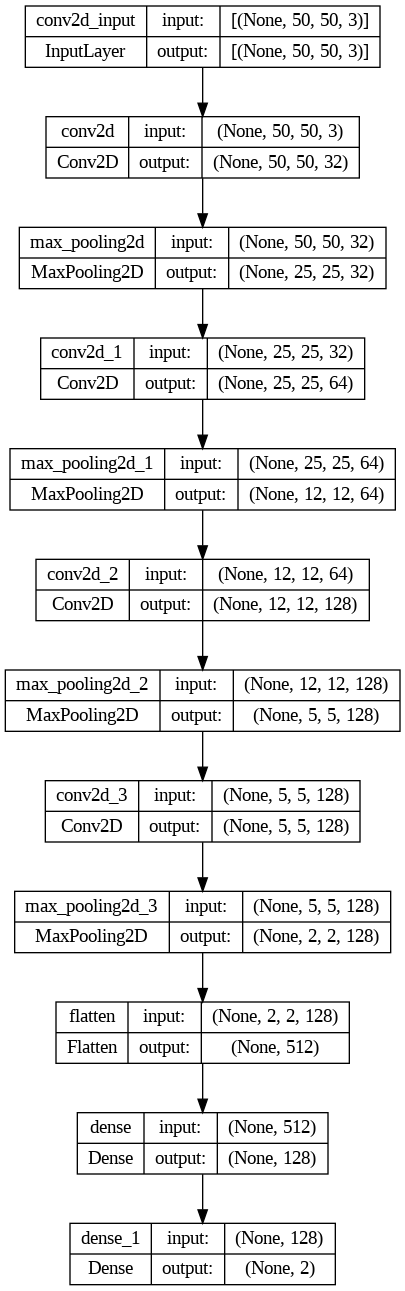

In [ ]:
tf.keras.utils.plot_model(model, "Histopathology_model.png", show_shapes=True)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# Training the model
history = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 65, batch_size = 85)

Epoch 1/65
3259/3259 [==============================] - 49s 11ms/step - loss: 0.1606 - accuracy: 0.9555 - val_loss: 0.1318 - val_accuracy: 0.9571
Epoch 2/65
3259/3259 [==============================] - 32s 10ms/step - loss: 0.1307 - accuracy: 0.9568 - val_loss: 0.1216 - val_accuracy: 0.9587
Epoch 3/65
3259/3259 [==============================] - 33s 10ms/step - loss: 0.1272 - accuracy: 0.9577 - val_loss: 0.1166 - val_accuracy: 0.9590
Epoch 4/65
3259/3259 [==============================] - 32s 10ms/step - loss: 0.1239 - accuracy: 0.9585 - val_loss: 0.1187 - val_accuracy: 0.9580
Epoch 5/65
3259/3259 [==============================] - 32s 10ms/step - loss: 0.1203 - accuracy: 0.9592 - val_loss: 0.1166 - val_accuracy: 0.9597
Epoch 6/65
3259/3259 [==============================] - 32s 10ms/step - loss: 0.1174 - accuracy: 0.9598 - val_loss: 0.1149 - val_accuracy: 0.9601
Epoch 7/65
3259/3259 [==============================] - 33s 10ms/step - loss: 0.1158 - accuracy: 0.9603 - val_loss: 0.1157 -

In [ ]:
model.evaluate(X_test,y_test)

1735/1735 [==============================] - 6s 3ms/step - loss: 0.0145 - accuracy: 0.9960


[0.014481434598565102, 0.996000349521637]

1735/1735 [==============================] - 5s 3ms/step


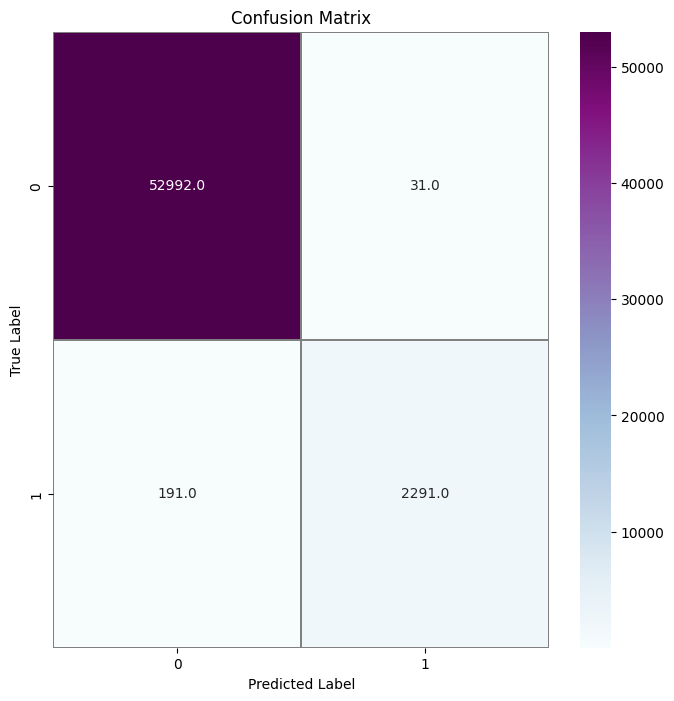

In [ ]:
from sklearn.metrics import confusion_matrix
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred,axis = 1)
Y_true = np.argmax(y_test,axis = 1)

confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
f,ax = plt.subplots(figsize=(8, 8))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01,cmap="BuPu",linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

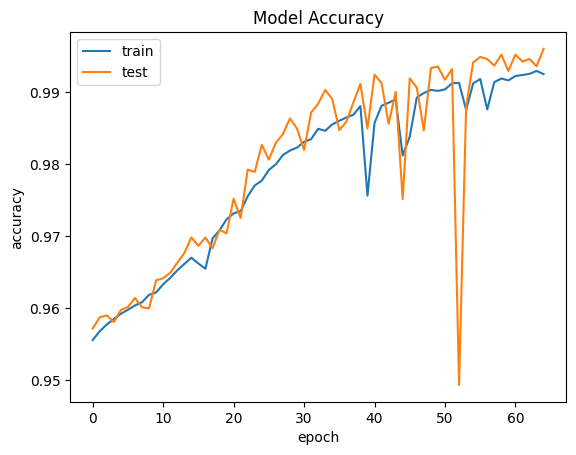

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

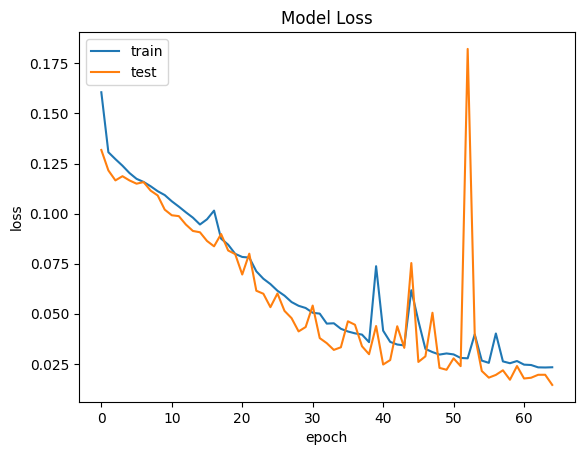

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# Make prediction
prediction = model.predict(X_test)
prediction

1735/1735 [==============================] - 3s 2ms/step


array([[1.0000000e+00, 2.0701815e-34],
       [1.0000000e+00, 4.9829868e-15],
       [9.9982232e-01, 1.7775227e-04],
       ...,
       [1.0000000e+00, 6.5861289e-19],
       [1.0000000e+00, 4.7852936e-31],
       [1.0000000e+00, 8.2330377e-21]], dtype=float32)

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, roc_auc_score, roc_curve, confusion_matrix, auc ,matthews_corrcoef
# Report of the results
prediction=np.argmax(prediction, axis=1)
y_test=np.argmax(y_test, axis=1)
print("Report of the result of Histopathology_data model : \n Confusion matrix : \n {} \n\nAccuracy Score:{}% \n\nPrecision Score:{}% \n\nRecall Score: {}% \n\nf1 score Score: {}%  \n\nmcc: {}%\n\nClassification Report : \n  {}".format(
      confusion_matrix(y_test,prediction),
      round(accuracy_score(y_test,prediction),3)*100 ,
      round(precision_score(y_test,prediction),3)*100,
      round(recall_score(y_test,prediction),3)*100,
      round(f1_score(y_test,prediction),3)*100,
      round(matthews_corrcoef(y_test,prediction),3)*100,
      classification_report(y_test,prediction)))

Report of the result of Histopathology_data model : 
 Confusion matrix : 
 [[52992    31]
 [  191  2291]] 

Accuracy Score:99.6% 

Precision Score:98.7% 

Recall Score: 92.30000000000001% 

f1 score Score: 95.39999999999999%  

mcc: 95.19999999999999%

Classification Report : 
                precision    recall  f1-score   support

           0       1.00      1.00      1.00     53023
           1       0.99      0.92      0.95      2482

    accuracy                           1.00     55505
   macro avg       0.99      0.96      0.98     55505
weighted avg       1.00      1.00      1.00     55505



In [ ]:
def img_plot(arr,index=0):
    plt.title('Test Image')
    plt.imshow(arr[index].astype('uint8'))

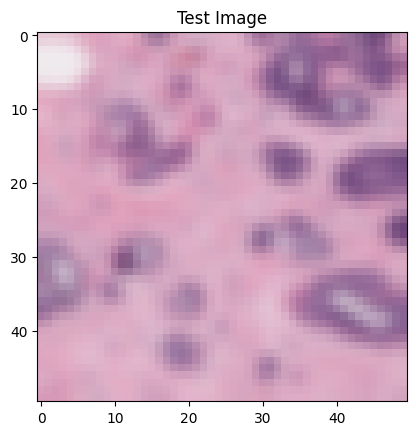

In [ ]:
index = 70
img_plot(X_test, index)

In [ ]:
input = X_test[index:index+1]

In [ ]:
pred =model.predict(input)[0].argmax()
label = y_test[index].argmax()

1/1 [==============================] - 0s 154ms/step


In [ ]:
print('Predicted Value using cnn model',pred)
print("True Value",label)

Predicted Value using cnn model 0
True Value 0
